In [1]:
import numpy as np

import matplotlib as mpl
import modules.tools as tools
import modules.models as models

import scipy.sparse.linalg as sla
import sys

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import os
import pickle
print(os.path.dirname(os.getcwd()))

/Users/alexanderlau/Documents/Science/Projects/NLSM_flat_band


In [3]:
from tqdm.notebook import tqdm # to have a progress bar for the loop

In [4]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=16)

In [5]:
s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

In [6]:
from numpy import cos, sin, pi, exp, sqrt

### Unstrained model

In [172]:
# calculate spectral function
Nx = 201
Ny = Nx

Ef = 0.0

kxs = np.linspace(-pi,pi,Nx)
kys = np.linspace(-pi,pi,Ny)
S = np.zeros((Nx,Ny))

ham = lambda kx, ky: models.H0(kx, ky, kz=0.0, t1=4.0, t2=1.)

for i,kx in enumerate(kxs):
    for j,ky in enumerate(kys):
        S[j,i] = tools.spectral_function_2D((kx,ky), ham, Ef)     

Text(0, 0.5, '$k_y$')

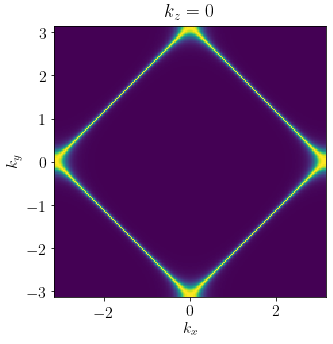

In [173]:
plt.figure(figsize=(5,5))
plt.title('$k_z=0$')
plt.imshow(S.transpose(), extent=tools.imshow_extent(kxs,kys), aspect=1)
#plt.axvline(0)
#plt.axhline(0)
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')

### Finite Model with strain

The strain term is implemented as a position-dependent prefactor $1-\frac{z}{R}$ of the hopping parameter w.r.t. the x direction. This describes a ray-like strain profile. It is a leading-order approximation and is only valid for small strain.

Let's look at the two limiting cases:
* For $z=-R$, we are at the focal point of the ray where the $x$ distance between adjacent sites goes to zero. Here, the prefactor is $1-\frac{z}{R}\rightarrow 2$. This is not realistic as we would expect an exponential dependence on the distance.
* For $z=R$, the hopping term vanishes as $1-\frac{z}{R}\rightarrow 0$. Also this is not physical, as the hopping amplitude should decline exponentially with $z$.

Hence, this approximation is only valid for $|z|\ll R$.

#### Negligible strain

In [196]:
R = 1e6
t1 = 4.0
t2 = 1.0
Lz = 100

In [183]:
Gamma = [0,0]
X = [pi, 0]
M = [pi, pi]

k_points = [X, Gamma, M]
k_labels = ['$X$', '$\Gamma$', '$M$']

In [184]:
params = dict(Lz=Lz, R=R, t1=t1, t2=t2)

In [185]:
kline0, energies0, evecs0 = tools.compute_bands_2D(models.H_strain, params, k_points)

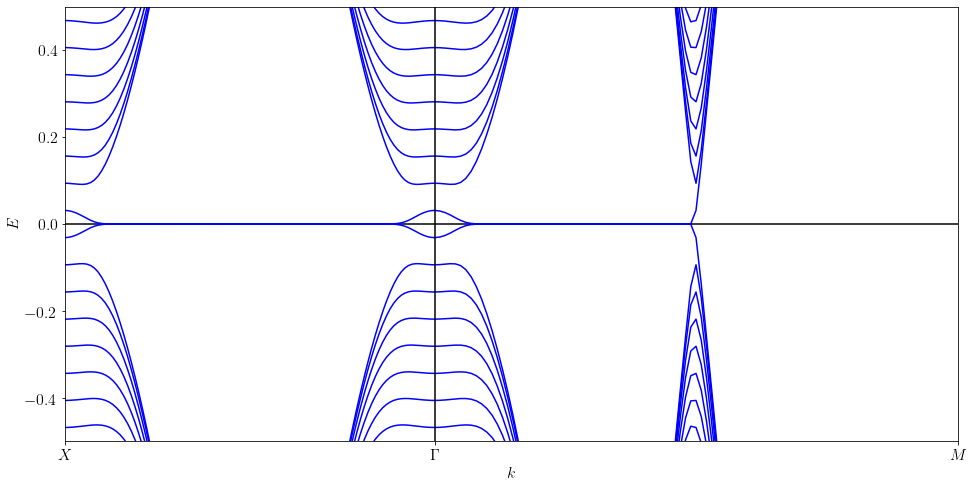

In [186]:
tools.plot_bands_2D(kline1, energies1, k_labels, ymin=-0.5,ymax=0.5)

In [180]:
# calculate spectral function
Nx = 101
Ny = Nx

Ef = 0.0

kxs = np.linspace(-pi,pi,Nx)
kys = np.linspace(-pi,pi,Ny)
S0 = np.zeros((Nx,Ny))

ham = lambda kx, ky: models.H_strain(kx, ky, Lz, R, t1, t2)

for i,kx in tqdm(list(enumerate(kxs))):
    for j,ky in enumerate(kys):
        S0[i,j] = tools.spectral_function_2D((kx,ky), ham, Ef)     

Text(0, 0.5, '$k_y$')

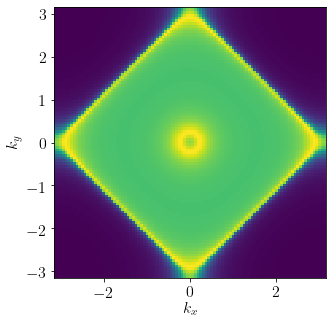

In [181]:
plt.figure(figsize=(5,5))
plt.imshow(S0.transpose(), extent=tools.imshow_extent(kxs,kys), aspect=1)
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')

In [194]:
i=50

state1 = tools.density(evecs1[i,:,Lz-1],2)
state2 = tools.density(evecs1[i,:,Lz],2)

Text(0, 0.5, '$|\\psi(z)|$')

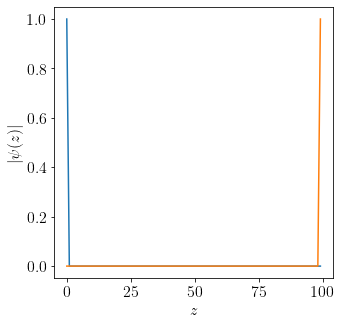

In [195]:
plt.figure(figsize=(5,5))
plt.plot(state1)
plt.plot(state2)
plt.xlabel('$z$')
plt.ylabel('$|\psi(z)|$')

The zero-energy states are surface states corresponding to the drumhead surface states of nodal-line semimetals

#### Sizable strain

Ensure that $L_z/2 < R$.

In [382]:
R = 100
t1 = 4.0
t2 = 1.0
Lz = 100

In [383]:
Gamma = [0,0]
X = [pi, 0]
M = [pi, pi]

k_points = [X, Gamma, M]
k_labels = ['$X$', '$\Gamma$', '$M$']

In [384]:
params = dict(Lz=Lz, R=R, t1=t1, t2=t2)

In [385]:
kline1, energies1, evecs1 = tools.compute_bands_2D(models.H_strain, params, k_points,Nk=200)

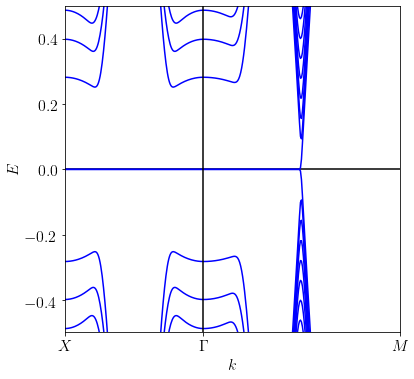

In [386]:
tools.plot_bands_2D(kline1, energies1, k_labels, ymin=-0.5,ymax=0.5, figsize=(6,6))

In [334]:
# calculate spectral function
Nx = 201
Ny = Nx

Ef = 0.0

kxs = np.linspace(-pi,pi,Nx)
kys = np.linspace(-pi,pi,Ny)
S1 = np.zeros((Nx,Ny))

ham = lambda kx, ky: models.H_strain(kx, ky, Lz, R, t1, t2)

for i,kx in tqdm(list(enumerate(kxs))):
    for j,ky in enumerate(kys):
        S1[i,j] = tools.spectral_function_2D((kx,ky), ham, Ef, eps=0.01)     

Text(0, 0.5, '$k_y$')

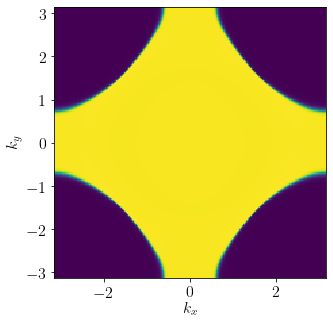

In [335]:
plt.figure(figsize=(5,5))
plt.imshow(S1.transpose(), extent=tools.imshow_extent(kxs,kys), aspect=1)
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')

In [339]:
S1_cut = (S1>200)

Text(0, 0.5, '$k_y$')

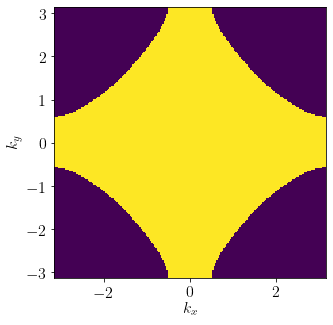

In [343]:
plt.figure(figsize=(5,5))
plt.imshow(S1_cut.transpose(), extent=tools.imshow_extent(kxs,kys), aspect=1)
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')

In [380]:
i=30

state1 = np.sqrt(tools.density(evecs1[i,:,Lz-1],2))
state2 = np.sqrt(tools.density(evecs1[i,:,Lz],2))

Text(0, 0.5, '$|\\psi(z)|$')

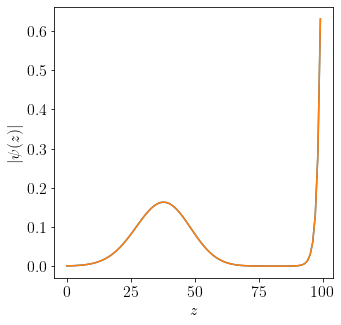

In [381]:
plt.figure(figsize=(5,5))
plt.plot(state1)
plt.plot(state2)
plt.xlabel('$z$')
plt.ylabel('$|\psi(z)|$')

#### Save to file for figures

In [387]:
params = dict(t1=t1, t2=t2, kxs=kxs, kys=kys, R=R, Lz=Lz)

In [388]:
# Write everything to a pickle file
path = os.path.dirname(os.getcwd()) + '/data/'
out_name = 'minimal_model_largeQ'
fp = open(path + out_name + '.p', 'wb')
pickle.dump(params, fp)
pickle.dump(kline1, fp)
pickle.dump(energies1, fp)
pickle.dump(evecs1[:,:,Lz-1:Lz+1], fp)
pickle.dump(S1, fp)
fp.close()